In [3]:
## 1) Import libraries and load datasets

%pip install xgboost

import os
import numpy as np
import pandas as pd
from pathlib import Path

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Import XGBoost
import xgboost as xgb
from xgboost import XGBClassifier
print('XGBoost version:', xgb.__version__)

# Paths (notebook in models/)
ROOT = Path('..')
DATA_DIR = ROOT / 'data' / 'election_data'
print('Data directory:', DATA_DIR)

# Load datasets
house = pd.read_csv(DATA_DIR / 'house_results_cleaned.csv')
census = pd.read_csv(DATA_DIR / 'census_2024_435_cleaned.csv')
state_pvi = pd.read_csv(DATA_DIR / 'state_pvi_cleaned.csv')

print(f'Loaded: {len(house)} house results, {len(census)} census records, {len(state_pvi)} state PVI records')

Note: you may need to restart the kernel to use updated packages.
XGBoost version: 3.2.0
Data directory: ..\data\election_data
Loaded: 18388 house results, 435 census records, 50 state PVI records


In [6]:
## 2) Preprocess: create target and merge datasets

# Create vote_pct from candidate_votes and total_votes
house['vote_pct'] = house['candidate_votes'] / house['total_votes']

# Create binary target: is_winner (candidate with max vote_pct per year+district)
house['is_winner'] = house['vote_pct'] == house.groupby(['year','district_id'])['vote_pct'].transform('max')

# Select key columns from house results (use party_clean instead of party)
house_subset = house[['year', 'district_id', 'candidate_name', 'party_clean', 'candidate_votes', 'total_votes', 'vote_pct', 'is_winner']].copy()
house_subset.rename(columns={'party_clean': 'party'}, inplace=True)

# Merge with census (district-level features)
if 'district_id' in census.columns:
    df = house_subset.merge(census, how='left', on='district_id')
else:
    print("Warning: 'district_id' not in census. Attempting fallback merge...")
    df = house_subset.copy()

# Merge with state PVI (partisan index by state)
# Check state_pvi columns first
print('State PVI columns:', state_pvi.columns.tolist())
pvi_merge_col = None
for col in ['pvi', 'PVI', 'Pvi']:
    if col in state_pvi.columns:
        pvi_merge_col = col
        break

if pvi_merge_col and 'state' in state_pvi.columns and 'state' in df.columns:
    df = df.merge(state_pvi[['state', pvi_merge_col]], how='left', on='state')
    print(f'Merged with PVI using column: {pvi_merge_col}')

print(f'Merged dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nDataset sample:')
print(df.head())

State PVI columns: ['state', 'pvi_score', 'pvi_label', 'state_lean', 'avg_dem_pct', 'avg_rep_pct']
Merged dataset shape: (18477, 253)
Missing values: 166111

Dataset sample:
   year district_id  candidate_name party  candidate_votes  total_votes  \
0  2000       AL-01     Dick Coffee     O            14031       165669   
1  2000       AL-01  Sonny Callahan     R           151188       165669   
2  2000       AL-01         Writein     O              450       165669   
3  2000       AL-02   Charles Woods     D            64958       222636   
4  2000       AL-02   Terry Everett     R           151830       222636   

   vote_pct  is_winner                                      district_name  \
0  0.084693      False  Congressional District 1 (119th Congress), Ala...   
1  0.912591       True  Congressional District 1 (119th Congress), Ala...   
2  0.002716      False  Congressional District 1 (119th Congress), Ala...   
3  0.291768      False  Congressional District 2 (119th Congress), 

In [7]:
## 3) Feature selection and train/test split

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove identifier and target columns from features
exclude_cols = ['votes', 'total_votes', 'vote_pct', 'is_winner', 'candidate_id', 'year']
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Categorical features
cat_cols = [c for c in ['party'] if c in df.columns]

print(f'Numeric features ({len(numeric_cols)}): {numeric_cols[:5]}...')
print(f'Categorical features: {cat_cols}')

# Prepare X, y
X = df[numeric_cols + cat_cols].fillna(0)
y = df['is_winner'].astype(int)

print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Class distribution: {y.value_counts().to_dict()}')

# Stratified train/val split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}, Val: {len(X_val)}')

Numeric features (243): ['candidate_votes', 'total_population', 'median_age', 'median_age_male', 'median_age_female']...
Categorical features: ['party']
X shape: (18477, 244), y shape: (18477,)
Class distribution: {0: 12795, 1: 5682}
Train: 14781, Val: 3696


In [8]:
## 4) Build preprocessing pipeline

# Numeric: scale
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Categorical: one-hot encode
cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', cat_transformer, cat_cols)
])

print('Preprocessor pipeline ready')

Preprocessor pipeline ready


In [13]:
## 5) Train XGBoost classifier (GPU-accelerated)

print('Building XGBoost pipeline with GPU acceleration...')

# Convert categorical columns to numeric codes for XGBoost (simpler approach)
X_train_numeric = X_train.copy()
X_val_numeric = X_val.copy()

# Map party to numeric
if 'party' in X_train_numeric.columns:
    party_map = {cat: idx for idx, cat in enumerate(X_train_numeric['party'].unique())}
    X_train_numeric['party'] = X_train_numeric['party'].map(party_map).fillna(-1).astype(int)
    X_val_numeric['party'] = X_val_numeric['party'].map(party_map).fillna(-1).astype(int)
    print(f'Encoded party column: {party_map}')

# XGBoost classifier with GPU settings (XGBoost 3.2.0)
# When device='cuda' is set, tree_method defaults to 'hist' for GPU support
xgb_model = XGBClassifier(
    n_estimators=500,         # Reduced for quick demo
    max_depth=6,
    learning_rate=0.05,
    tree_method='hist',       # Use 'hist' with device='cuda'
    device='cuda',            # Use CUDA device (XGBoost 3.1+)
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=50  # Early stopping rounds
)

print('Starting training on GPU...')
# Fit directly with numeric data
xgb_model.fit(
    X_train_numeric, y_train,
    eval_set=[(X_val_numeric, y_val)],
    verbose=20
)

print('Training complete!')
print(f'Best score: {xgb_model.best_score}')

Building XGBoost pipeline with GPU acceleration...
Encoded party column: {'O': 0, 'R': 1, 'D': 2}
Starting training on GPU...


c:\Users\B\anaconda3\envs\gpu_env\lib\site-packages\xgboost\callback.py:385: UserWarning: [18:41:08] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.58543
[20]	validation_0-logloss:0.30948
[40]	validation_0-logloss:0.24043
[60]	validation_0-logloss:0.21781
[80]	validation_0-logloss:0.20904
[100]	validation_0-logloss:0.20523
[120]	validation_0-logloss:0.20186
[140]	validation_0-logloss:0.19696
[160]	validation_0-logloss:0.19494
[180]	validation_0-logloss:0.19165
[200]	validation_0-logloss:0.19013
[220]	validation_0-logloss:0.18948
[240]	validation_0-logloss:0.18645
[260]	validation_0-logloss:0.18635
[280]	validation_0-logloss:0.18635
[300]	validation_0-logloss:0.18656
[320]	validation_0-logloss:0.18551
[340]	validation_0-logloss:0.18625
[360]	validation_0-logloss:0.18683
[362]	validation_0-logloss:0.18698
Training complete!
Best score: 0.1850411319325669


In [15]:
## 6) Evaluate model performance

# Predictions (using numeric data)
train_preds = xgb_model.predict(X_train_numeric)
val_preds = xgb_model.predict(X_val_numeric)

# Accuracy
train_acc = accuracy_score(y_train, train_preds)
val_acc = accuracy_score(y_val, val_preds)

print(f'Train Accuracy: {train_acc:.4f}')
print(f'Val Accuracy: {val_acc:.4f}')

print('\n' + '='*50)
print('Classification Report (Validation Set)')
print('='*50)
print(classification_report(y_val, val_preds))

c:\Users\B\anaconda3\envs\gpu_env\lib\site-packages\xgboost\core.py:751: UserWarning: [18:41:40] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Train Accuracy: 0.9619
Val Accuracy: 0.9159

Classification Report (Validation Set)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2559
           1       0.86      0.87      0.86      1137

    accuracy                           0.92      3696
   macro avg       0.90      0.90      0.90      3696
weighted avg       0.92      0.92      0.92      3696



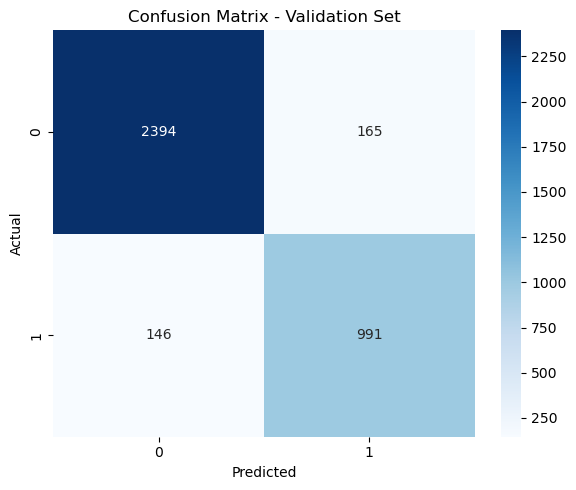

In [16]:
## 7) Visualize confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
## 8) Save trained model

OUT_DIR = Path('.') 
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save pipeline
model_path = OUT_DIR / 'xgb_gpu_pipeline.joblib'
joblib.dump(clf_pipeline, model_path)
print(f'Saved pipeline to: {model_path}')

# Save feature names for later use
feature_names = numeric_cols + cat_cols
features_path = OUT_DIR / 'feature_names.txt'
with open(features_path, 'w') as f:
    for name in feature_names:
        f.write(name + '\n')
print(f'Saved feature names to: {features_path}')

In [ ]:
## 9) Prediction helper functions

def load_model(model_path='xgb_gpu_pipeline.joblib'):
    """Load the saved XGBoost pipeline."""
    return joblib.load(model_path)

def predict_on_data(data_df, model=None, numeric_cols=numeric_cols, cat_cols=cat_cols):
    """
    Make predictions on new data.
    
    Args:
        data_df: DataFrame with same features as training data
        model: Loaded pipeline (if None, loads from file)
        numeric_cols: List of numeric column names
        cat_cols: List of categorical column names
    
    Returns:
        Dictionary with predictions and probabilities
    """
    if model is None:
        model = load_model()
    
    # Prepare features
    X_new = data_df[numeric_cols + cat_cols].fillna(0)
    
    # Predict
    preds = model.predict(X_new)
    probs = model.predict_proba(X_new)[:, 1]
    
    return {
        'predictions': preds,
        'probabilities': probs,
        'is_winner': preds == 1
    }

print('Prediction helpers loaded. Ready to make predictions on new data.')

In [ ]:
## 10) Example: Make predictions on sample data

# Example: predict on first 5 validation samples
sample_data = X_val.iloc[:5].copy()

result = predict_on_data(sample_data, model=clf_pipeline)

print('Sample Predictions:')
print(f"  Predictions (0/1): {result['predictions']}")
print(f"  Probabilities: {result['probabilities']}")
print(f"  Is Winner: {result['is_winner']}")

# Compare with actual
print(f"\nActual outcomes: {y_val.iloc[:5].values}")